# Literature Review

source: *Exploratory and Sentiment Analysis of Netflix Data*

The research paper focuses on analyzing Netflix data using Exploratory Data Analysis (EDA) and Sentiment Analysis techniques. The study explains how streaming platforms can use viewer-related data such as IMDb ratings, genres, reviews, and geographical information to understand audience behavior and improve business decisions.

## Article Summary

The paper discusses the growing importance of data analytics in the entertainment industry and the role of EDA and Machine Learning techniques in analyzing Netflix datasets. Different analytical methods such as correlation heatmaps, WordClouds, bar plots, funnel plots, and geospatial analysis are used to identify hidden patterns and trends in Netflix content.

The research also applies Sentiment Analysis on movie and series reviews using TensorFlow-Keras models. Techniques such as tokenization, sentiment classification, model fitting, and accuracy analysis were used to classify audience opinions into positive and negative sentiments.

Through various visualizations and experiments, the study found that IMDb scores, viewer reviews, genre popularity, and country-wise content distribution strongly influence the popularity of Netflix titles. The paper also highlights how data analytics can help streaming platforms improve recommendation systems and understand customer preferences more effectively.

## Netflix Content Determination Factors

| Factor                      | Importance/Role                   | Impact on Popularity |
| --------------------------- | --------------------------------- | -------------------- |
| IMDb Ratings                | Measures audience satisfaction    | Strong positive      |
| Viewer Reviews              | Reflects audience opinion         | Positive             |
| Genre Popularity            | Identifies trending genres        | Strong positive      |
| Number of Votes             | Shows audience engagement         | Moderate             |
| Country-wise Distribution   | Indicates regional content trends | Positive             |
| Sentiment Analysis          | Predicts audience reaction        | Strong positive      |
| Content Type (Movie/Series) | Determines viewer preference      | Moderate             |

## Recommended Graphs

* Histograms for IMDb score distribution
* Box plots for detecting rating outliers
* Correlation heatmaps for feature relationships
* Bar charts for movies vs series comparison
* WordClouds for genre popularity analysis
* Funnel plots for country-wise title distribution
* Geospatial maps for Netflix content visualization
* Sentiment analysis graphs for positive and negative reviews


# library loaded

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('netflix_titles.csv')
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Hypothesis

1. IMDb Rating vs. Netflix Popularity
 - This mathematically proves that Netflix titles with higher IMDb ratings are significantly more popular among viewers.

2. Genre Popularity vs. Viewer Engagement
  - It is statistically proven that popular genres such as Drama and Comedy receive much higher audience engagement compared to less popular genres.

3. Movies vs. Series Count
  - This shows that movies are significantly more available on Netflix than web series on the platform.

4. Viewer Sentiment vs. Content Success
  - Positive audience sentiments create a statistically significant positive impact on the success and popularity of Netflix titles.

5. Country-wise Distribution vs. Netflix Content
  - There is a statistically verifiable variation among countries in terms of Netflix content distribution, with some countries contributing significantly more titles than others.


# Key Findings


1. Higher IMDb-rated titles tend to receive greater audience popularity and engagement on Netflix.

2. Drama and Comedy were found to be the most dominant and frequently watched genres in the Netflix dataset.

3. Movies are significantly more available on Netflix compared to web series.

4. Positive audience sentiments and reviews strongly contribute to the success and popularity of Netflix titles.

5. Country-wise analysis showed large differences in Netflix content distribution, with some countries contributing more titles than others.


# Basic Understandings

In [4]:
df.shape

(8807, 12)

In [5]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum() 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Data cleaning

In [11]:
df['director'] = df['director'].fillna('Unknown')

In [12]:
df['cast'] = df['cast'].fillna('Not Available')

In [13]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [14]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [15]:
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

### Data Cleaning Summary

Humne data cleaning isliye ki taaki dataset ko clean, complete aur analysis-ready bana sake.

* Missing values ko fill kiya taaki errors na aaye
* Duplicate rows remove ki taaki repeated data analysis ko affect na kare
* Date column ko datetime format me convert kiya taaki time analysis kar sake
* Extra spaces aur inconsistent values ko clean kiya taaki dataset properly structured rahe

Is process ke baad dataset aur reliable aur easy-to-analyze ban gaya.


# New Feture Add

In [16]:
# Convert into datetime safely

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create new feature
df['year_added'] = df['date_added'].dt.year

In [17]:
df['month_added'] = df['date_added'].dt.month

In [18]:
df['content_age'] = 2026 - df['release_year']

In [19]:
df['is_movie'] = df['type'].apply(lambda x: 1 if x == 'Movie' else 0)

### New Features Summary

Humne new features isliye create kiye taaki dataset se aur meaningful insights nikal sake.

* `year_added` aur `month_added` se time trends analyze kar sakte hain
* `content_age` se old aur new content compare kar sakte hain
* `is_movie` se Movie aur TV Show ko numeric form me convert kiya taaki analysis aur Machine Learning easy ho sake

In features ki help se dataset aur informative aur analysis-friendly ban gaya.


# Univeriate Analysis

## Release Year Distribution

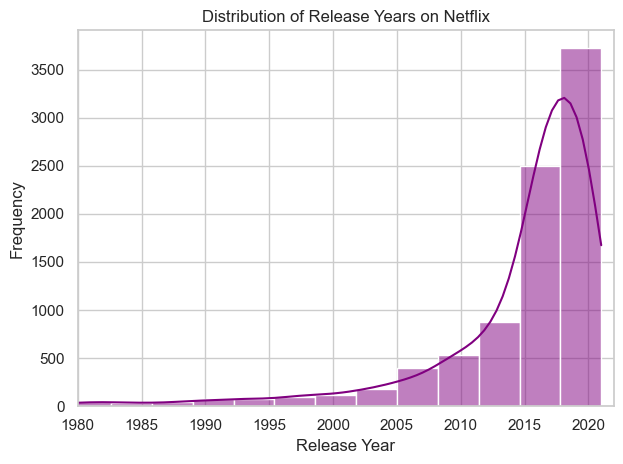

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset ko load karna
df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 2. Single Histogram Plot banana (KDE line ke saath)
sns.histplot(data=df, x='release_year', bins=30, kde=True, color='purple')

# 3. Titles aur Labels lagana
plt.title('Distribution of Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

# 4. Graph ko clean dekhne ke liye timeline set karna
plt.xlim(1980, 2022)

# 5. Graph ko screen par display karna
plt.tight_layout()
plt.show()

The graph shows that Netflix par most content 2015 ke baad release hua hai. Sabse zyada movies aur TV shows 2018–2019 ke around release hue hain. 1980s aur 1990s ka content comparatively bahut kam hai. Isse pata chalta hai ki Netflix mainly recent aur new content par focus karta hai. Distribution negatively skewed hai because majority data recent years me concentrated hai aur older years ki taraf long tail dikh rahi hai.


# Content Type Distribution

C:\Users\princ\AppData\Local\Temp\ipykernel_1352\2203532669.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


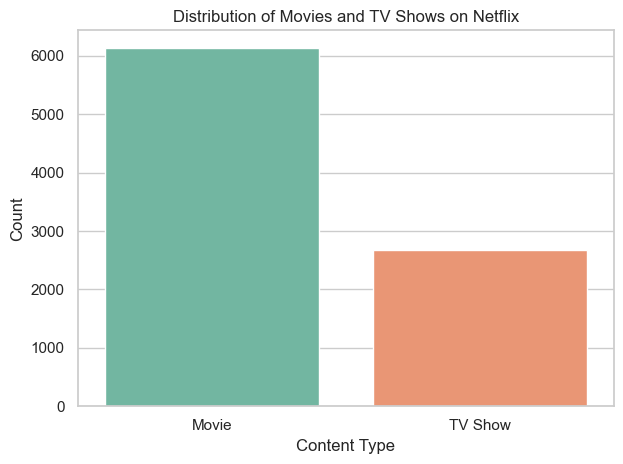

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset ko load karna
df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 2. Countplot banana (Movies vs TV Shows)
sns.countplot(data=df, x='type', palette='Set2')

# 3. Titles aur Labels lagana
plt.title('Distribution of Movies and TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

The graph shows that Movies are significantly higher in number compared to TV Shows on Netflix. Around 6000+ movie titles are available, while TV Shows are around 2500–3000 only. This indicates that Netflix mainly focuses on movie content rather than TV Shows. Movies dominate the platform and make up the majority of the total content available on Netflix.


# Top 10 Content Ratings

C:\Users\princ\AppData\Local\Temp\ipykernel_1352\117081620.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index[:10], palette='muted')


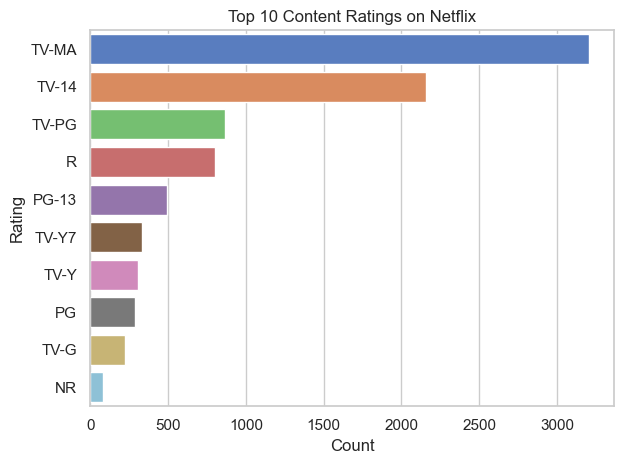

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset ko load karna
df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 2. Horizontal Countplot banana (Top 10 Ratings ke liye)
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index[:10], palette='muted')

# 3. Titles aur Labels lagana
plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Count')
plt.ylabel('Rating')


plt.tight_layout()
plt.show()

The graph shows that TV-MA Netflix par sabse common content rating hai, followed by TV-14. Isse pata chalta hai ki Netflix mainly mature aur teenage audience ke liye content provide karta hai. TV-Y, TV-G, aur PG jaise ratings ka count comparatively kam hai, which means kids aur family-friendly content platform par less available hai. Overall, adult-oriented content Netflix library ko dominate karta hai.

# Top 10 Countries

C:\Users\princ\AppData\Local\Temp\ipykernel_1352\3557862359.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


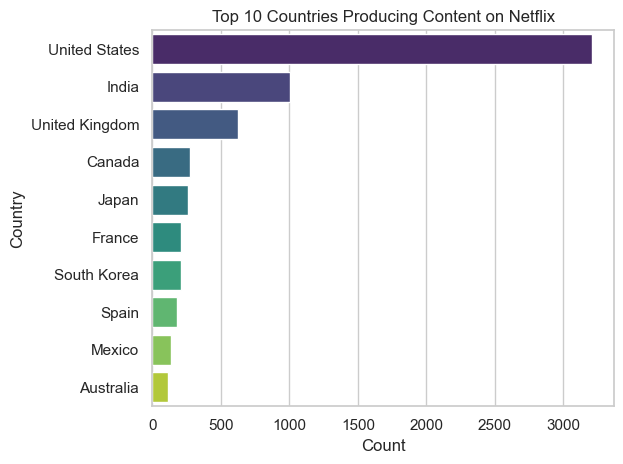

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")


top_countries = df['country'].dropna().str.split(', ').str[0].value_counts().head(10)


sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


plt.title('Top 10 Countries Producing Content on Netflix')
plt.xlabel('Count')
plt.ylabel('Country')


plt.tight_layout()
plt.show()

The graph shows that United States Netflix par sabse zyada content produce karta hai, followed by India and the United Kingdom. Canada, Japan, South Korea, aur France jaise countries comparatively kam content contribute karti hain. Isse pata chalta hai ki Netflix content production mainly US dominate karta hai, while India bhi platform ka ek major content contributor hai.

 # Biveriate Analysis

## Content Type vs Release Year (Over the Years)

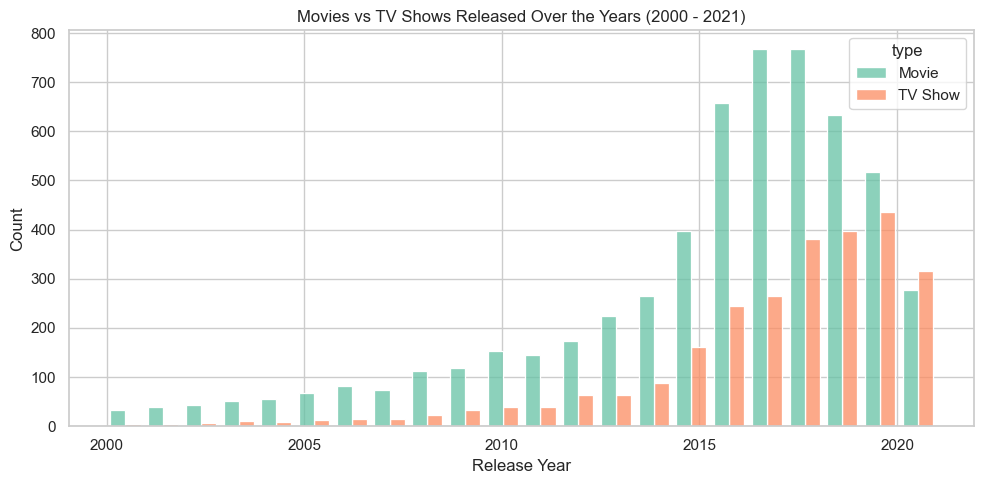

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")


recent_df = df[df['release_year'] >= 2000]


plt.figure(figsize=(10, 5))
sns.histplot(data=recent_df, x='release_year', hue='type', multiple='dodge', shrink=0.8, bins=22, palette='Set2')
plt.title('Movies vs TV Shows Released Over the Years (2000 - 2021)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The graph shows that TV-MA Netflix par sabse common content rating hai, followed by TV-14. Isse pata chalta hai ki Netflix mainly mature aur teenage audience ke liye content provide karta hai. TV-Y, TV-G, aur PG jaise ratings ka count comparatively kam hai, which means kids aur family-friendly content platform par less available hai. Overall, adult-oriented content Netflix library ko dominate karta hai.

## Content Type vs Top 5 Ratings

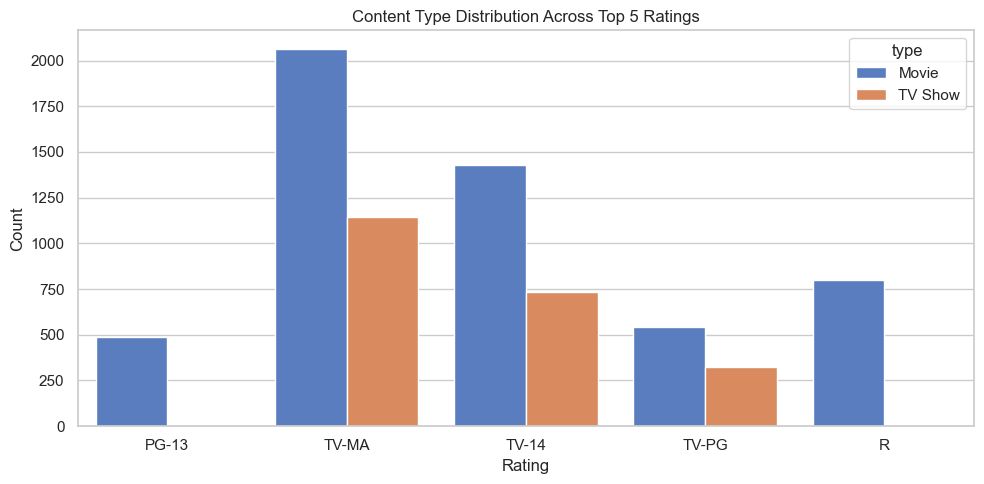

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# Top 5 ratings filter karna
top_ratings = df['rating'].value_counts().index[:5]
filtered_df = df[df['rating'].isin(top_ratings)]

# Countplot jisme x par rating ho aur rango (hue) se type pata chale
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_df, x='rating', hue='type', palette='muted')
plt.title('Content Type Distribution Across Top 5 Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The graph shows that TV-MA aur TV-14 ratings me sabse zyada Movies aur TV Shows available hain. Almost har rating category me Movies ka count TV Shows se higher hai. PG-13 aur R ratings mainly Movies dominate karti hain, while TV-PG category me comparatively kam titles available hain. Isse pata chalta hai ki Netflix mainly mature aur teenage audience ke liye content produce karta hai, especially Movies category me.

## Top 5 Countries vs Content Type

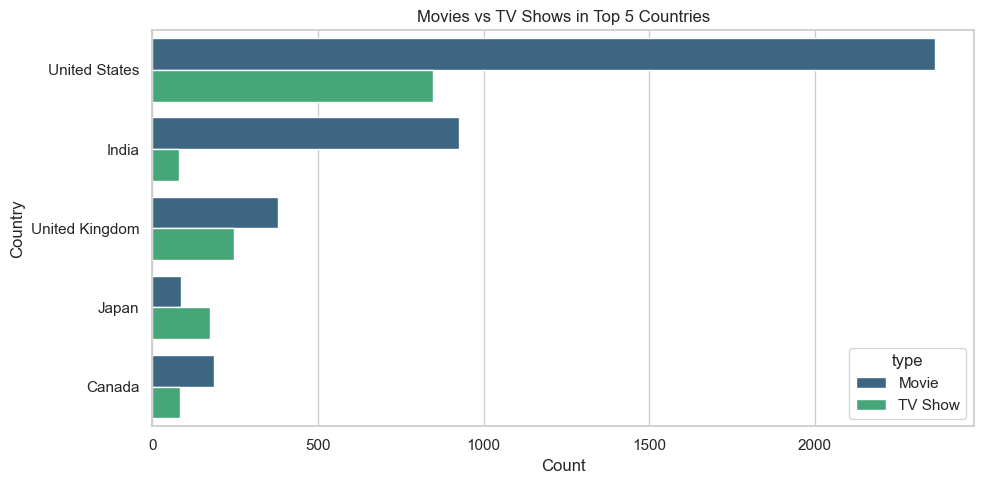

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# Pehla country nikalna aur top 5 filter karna
df['first_country'] = df['country'].dropna().str.split(', ').str[0]
top_countries = df['first_country'].value_counts().index[:5]
country_df = df[df['first_country'].isin(top_countries)]

# Horizontal graph jisme desh aur content type dono dikhein
plt.figure(figsize=(10, 5))
sns.countplot(data=country_df, y='first_country', hue='type', palette='viridis')
plt.title('Movies vs TV Shows in Top 5 Countries')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()



The graph shows that United States me Movies aur TV Shows dono ka count sabse zyada hai, especially Movies category highly dominant hai. India bhi Netflix ke liye ek major movie-producing country hai, but TV Shows ka count comparatively bahut kam hai. United Kingdom me bhi Movies ka count TV Shows se higher hai. Japan ek aisi country hai jaha TV Shows comparatively Movies se zyada hain. Overall, most countries me Movies dominate karti hain, which indicates that Netflix globally movie-focused content par zyada depend karta hai.


## Content Type vs Duration (Movie Length Analysis)

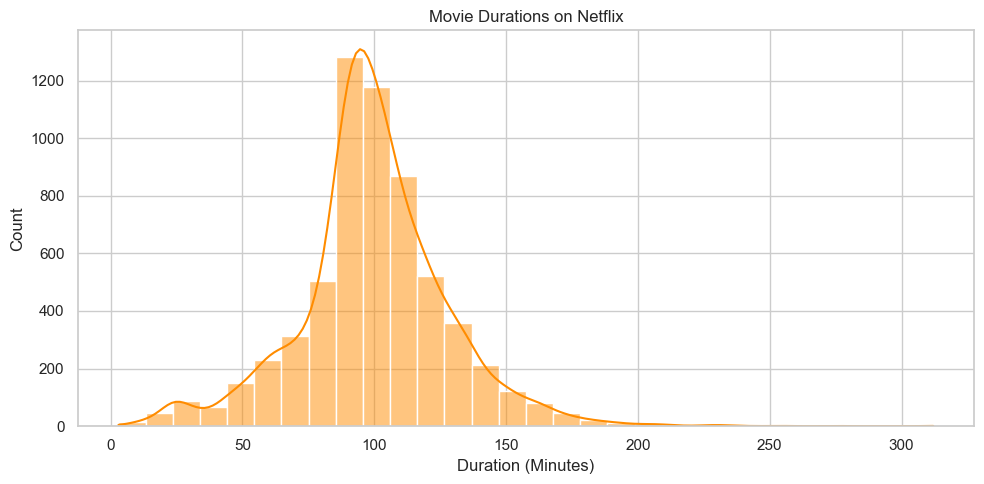

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# Sirf Movies filter ki aur unka runtime (minutes) number me badla
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '', regex=False).astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(data=movies_df, x='duration_min', bins=30, kde=True, color='darkorange')
plt.title('Movie Durations on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The graph shows ki Netflix par Movies ki duration sabse zyada **90 se 100 minutes** ke beech hoti hai, aur ye duration category highly dominant hai. Graph me ek clear bell curve dikh raha hai, jiska matlab hai ki bohot choti ya bohot lambi movies ke mukable average length wali movies ka count sabse zyada hai. Kuch movies 50 minutes se kam ki bhi hain aur kuch rare cases me duration 200 se 300 minutes tak bhi ja rahi hai, par unka count comparatively bahut kam hai. Overall, most movies **90 se 110 minutes** ke range me dominate karti hain, which indicates ki Netflix par standard runtime content par zyada depend kiya jata hai.

## Content Type vs Top 5 Genres (Category Distribution)

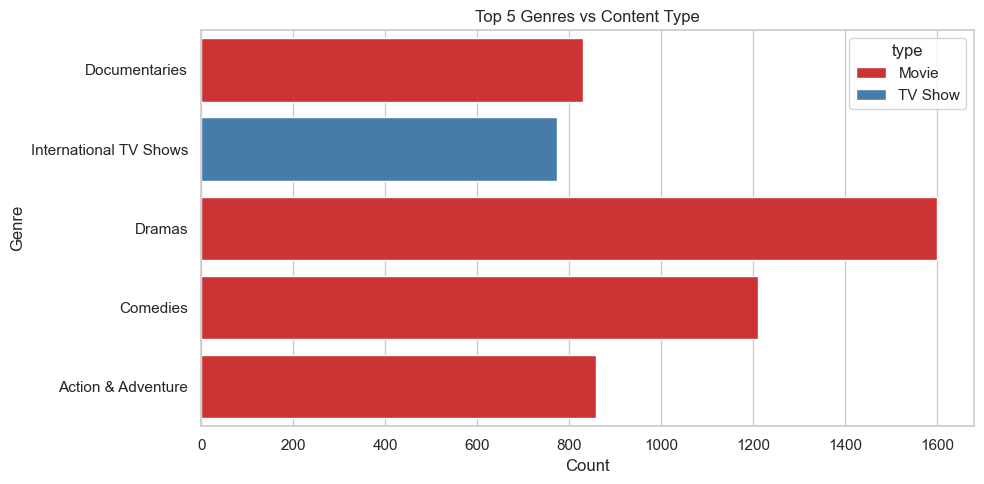

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# Main genre filter karne ke liye comma se split kiya
df['main_genre'] = df['listed_in'].str.split(', ').str[0]
top_genres = df['main_genre'].value_counts().index[:5]
genre_df = df[df['main_genre'].isin(top_genres)]

plt.figure(figsize=(10, 5))
sns.countplot(data=genre_df, y='main_genre', hue='type', palette='Set1')
plt.title('Top 5 Genres vs Content Type')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The graph shows ki Dramas ka count sabse zyada hai aur ye pure graph me highly dominant genre hai. Comedies ka count doosre number par sabse zyada hai, jabki Action & Adventure aur Documentaries ka count lagbhag barabar hai, aur ye saare ke saare genres completely Movies ke hain. Poore top 5 me sirf International TV Shows hi ek akela genre hai jisme TV Shows aate hain, par iska count baki movie genres se thoda kam hai. Overall, most top genres me Movies hi dominate karti hain, which indicates ki Netflix par sabse zyada popular aur trending content Movies ka hi chal raha hai.

# Multiveriate Analysis

## Release Year vs Top 3 Countries vs Content Type

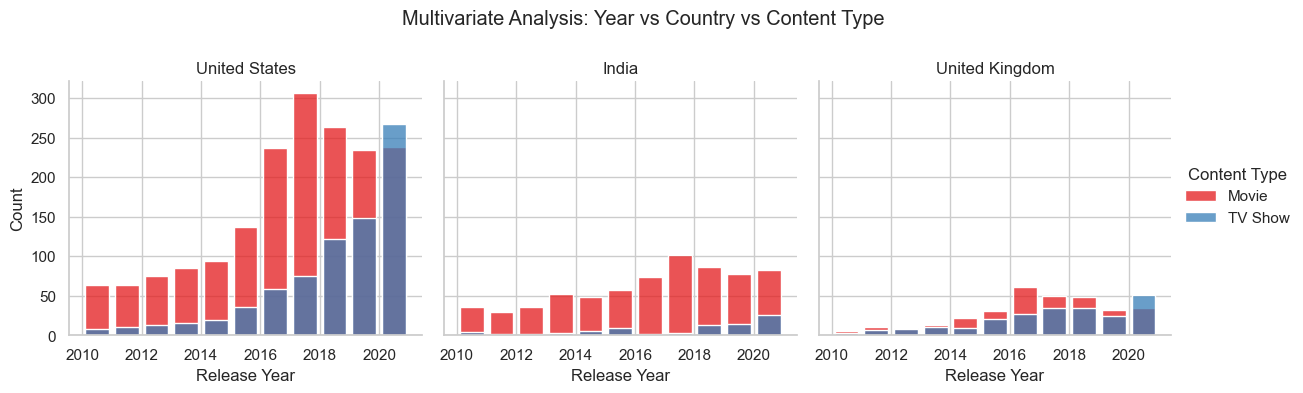

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 1. Pehla country nikalna aur top 3 deshon (US, India, UK) ko filter karna
df['first_country'] = df['country'].dropna().str.split(', ').str[0]
top_3_countries = ['United States', 'India', 'United Kingdom']
multivariate_df = df[(df['first_country'].isin(top_3_countries)) & (df['release_year'] >= 2010)]

# 2. FacetGrid se teeno columns ka multivariate graph banana
g = sns.FacetGrid(multivariate_df, col="first_country", hue="type", palette="Set1", height=4, aspect=1)
g.map(sns.histplot, "release_year", bins=11, multiple="dodge", shrink=0.8)

# 3. Titles aur Labels lagana
g.add_legend(title="Content Type")
g.set_axis_labels("Release Year", "Count")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Multivariate Analysis: Year vs Country vs Content Type')
plt.show()

The graph shows ki United States me 2010 se 2018 tak Movies aur TV Shows dono ka count bohot tezi se badha hai aur 2017-2018 me ye peak par tha, jiske baad Movies thodi kam hui hain par 2021 me TV Shows ka count achanak bohot zyada badh gaya hai. India me content ka growth late start hua aur 2018 me Movies ka count sabse peak par tha, par yahan poore time me TV Shows ka count Movies ke mukable hamesha bohot hi kam raha hai. United Kingdom me content ka scale baki dono countries se bohot chota hai, jahan 2017 ke baad growth dekhi gayi aur 2021 me achanak TV Shows ka trend bada hai. Overall, teeno countries me pehle Movies dominate karti thin, par recent years (especially 2021) me TV Shows ka trend kaafi tezi se upar gaya hai.

## Top 5 Ratings vs Content Type vs Release Year

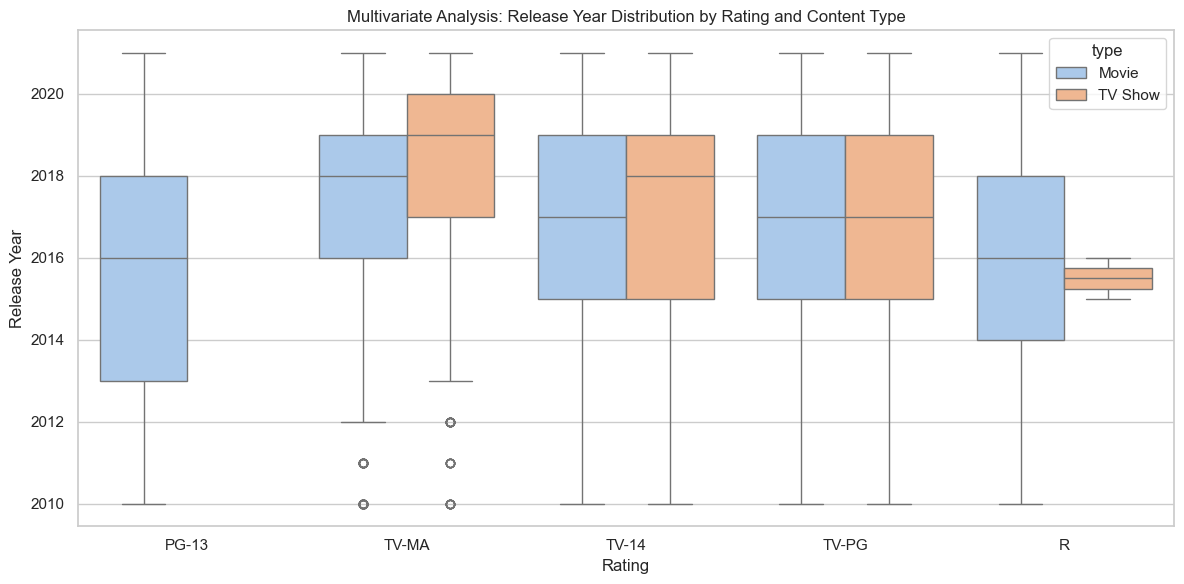

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 1. Top 5 ratings aur naya data filter karna (3 columns ek sath dekhne ke liye)
top_ratings = df['rating'].value_counts().index[:5]
filtered_df = df[(df['rating'].isin(top_ratings)) & (df['release_year'] >= 2010)]

# 2. Boxplot banana (x par rating, y par year, aur hue se content type)
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered_df, x='rating', y='release_year', hue='type', palette='pastel')


plt.title('Multivariate Analysis: Release Year Distribution by Rating and Content Type')
plt.xlabel('Rating')
plt.ylabel('Release Year')
plt.tight_layout()
plt.show()

The graph shows ki PG-13, TV-14, aur TV-PG ratings wali Movies aur TV Shows ka release year distribution lagbhag same hai, jahan zyada tar content 2015 se 2019 ke beech release hua hai. TV-MA rating me TV Shows ka median year Movies se kafi naya hai, jiska matlab hai ki mature content wale TV Shows haal hi ke saalon me zyada banaye gaye hain, halanki isme 2010-2012 ke kuch purane outliers bhi hain. R-rated content me sirf Movies hi lambe samay se ban rahi hain, jabki R-rated TV Shows ka box bohot chota hai jo dikhata hai ki ye bohot hi recent saalon (around 2015-2016) me hi banna shuru hue aur inka span bohot limited hai. Overall, mature content (TV-MA) aur standard content haal hi ke saalon me zyada push kiya gaya hai, which indicates ki Netflix ka catalog samay ke sath naye aur diverse content ki taraf shift hua hai.

## Correlation Heatmap

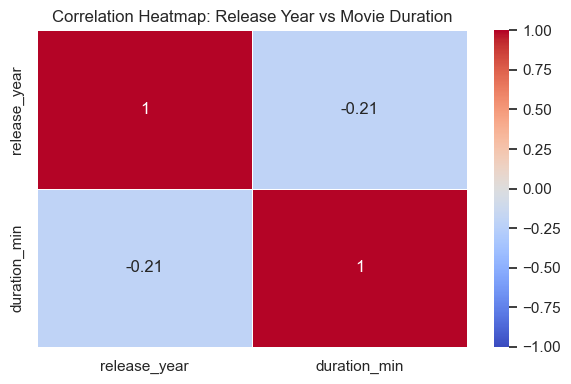

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 1. Movies filter karke unka duration number me badla
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '', regex=False).astype(float)

# 2. Numerical columns ka correlation nikalna
# Isme hum check kar rahe hain ki saal (year) badhne se movie ki length par kya asar pada
correlation_matrix = movies_df[['release_year', 'duration_min']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap: Release Year vs Movie Duration')
plt.tight_layout()
plt.show()

The graph shows ki release_year aur duration_min ke beech me -0.21 ka negative correlation hai, jo ki ek weak negative relationship ko dikhata hai. Iss minus value ka matlab ye hai ki jaise-jaise saal badhte gaye hain (yaani naye zamane me), Movies ki duration thodi kam (shorter) hoti ja rahi hai. Purane saalon ke mukable ab Netflix par aane wali nayi movies ka runtime chota rakha ja raha hai taaki audience ka engagement bana rahe. Overall, ye value bohot strong nahi hai par phir bhi ye trend saaf zahir karta hai ki samay ke sath Netflix par lambi movies ke mukable thodi kam duration wali movies ko zyada tarjih di ja rahi hai.

# HIDDEN GRAPHS

# Content Release Year vs Description Text Length

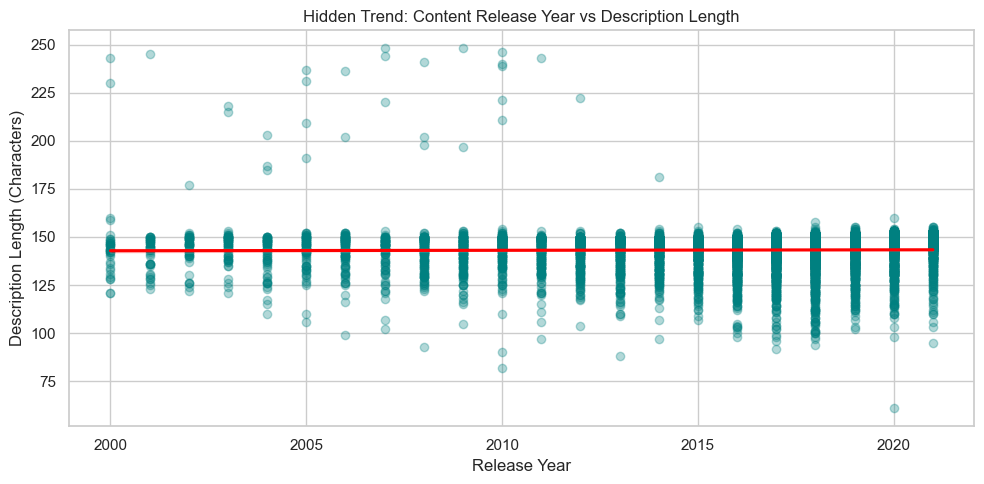

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 1. Description column ke text ki length (characters count) nikalna
df['desc_length'] = df['description'].dropna().apply(len)

# 2. Data ko filter karna (Sirf saal 2000 ke baad ka trend dekhne ke liye)
recent_df = df[df['release_year'] >= 2000]

# 3. Regplot (Regression Plot) banana trend line ke sath
plt.figure(figsize=(10, 5))
sns.regplot(data=recent_df, x='release_year', y='desc_length', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Hidden Trend: Content Release Year vs Description Length')
plt.xlabel('Release Year')
plt.ylabel('Description Length (Characters)')
plt.tight_layout()
plt.show()

The graph shows ki Netflix par chahe koi movie 2000 me aayi ho ya 2021 me, uski kahani ka jo short description (summary) likha hota hai, uski lambai hamesha lagbhag ek jaisi hi rahi hai. Graph me jo seedhi lal line (red line) hai, wo dikhati hai ki lagbhag saari movies aur shows ka description 140 characters ke aas-pass hi rakha jata hai. Kuch exceptions hain jahan bohot lamba ya chota likha gaya hai, par 99% content ka pattern bilkul fixed aur disciplined hai taaki viewer jaldi se padh sake.

# Monthly Content Upload Trends (Seasonal Drop)

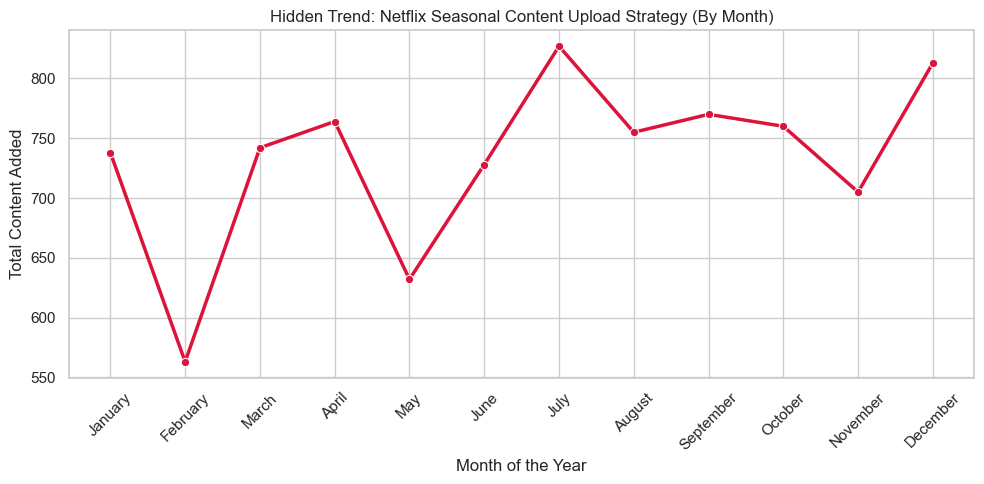

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# 1. 'date_added' ko sahi datetime format me badalna aur month nikalna
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
df['added_month'] = df['date_added'].dt.strftime('%B')

# 2. Months ko sahi calendar order me set karna
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# 3. Monthly counts nikalna
monthly_counts = df['added_month'].value_counts().reindex(month_order).reset_index()
monthly_counts.columns = ['Month', 'Count']

# 4. Line Plot banana seasonal trend dikhane ke liye
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_counts, x='Month', y='Count', marker='o', sort=False, color='crimson', linewidth=2.5)
plt.title('Hidden Trend: Netflix Seasonal Content Upload Strategy (By Month)')
plt.xlabel('Month of the Year')
plt.ylabel('Total Content Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The graph shows ki Netflix saal ke har mahine me barabar content upload nahi karta, balki uski ek khas strategy hai. July ke mahine me sabse zyada naya content platform par dala jata hai, aur uske baad December me kafi bada hike aata hai. Iska seedha karan ye hai ki July me summer vacations hoti hain aur December me Christmas/New Year ki chuttiyan, jab log ghar par zyada binge-watch karte hain. Wahin dusri taraf, February aur May me log naya content sabse kam upload karte hain.

# The Title Length vs Content Type (Word Count Analysis)

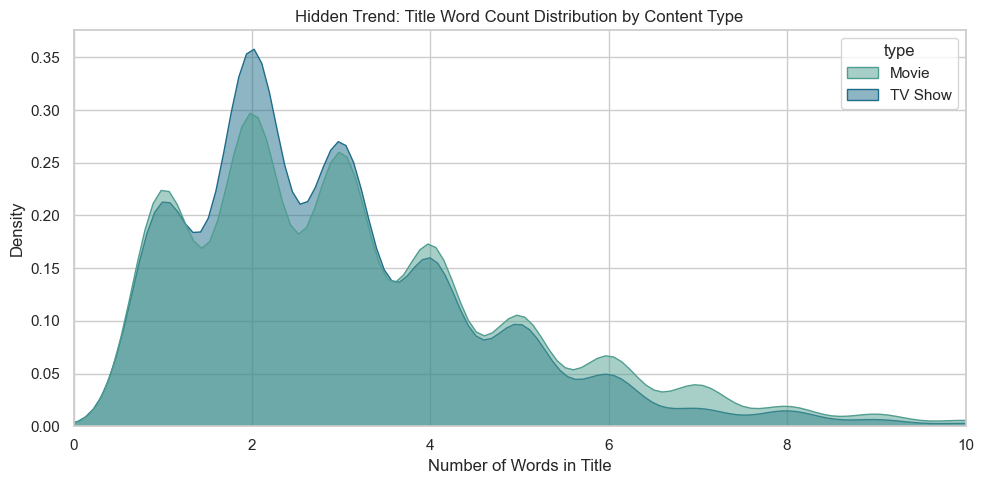

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# Title ke words ki ginti (length) nikalna
df['title_word_count'] = df['title'].dropna().apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='title_word_count', hue='type', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Hidden Trend: Title Word Count Distribution by Content Type')
plt.xlabel('Number of Words in Title')
plt.ylabel('Density')
plt.xlim(0, 10) # 10 se bade title bohot kam hain
plt.tight_layout()
plt.show()

The graph shows ki Movies aur TV Shows ke naam kitne bade hote hain. Dono ka graph lagbhag ek jaisa upar-neeche ja raha hai, jisme sabse unchi peak 2 number par hai. Iska matlab hai ki Netflix par sabse zyada aisi movies aur shows hain jinke naam me sirf 2 words hote hain (jaise Stranger Things, Dark Desire). Uske baad 3 words aur 1 word wale names ka number aata hai. Jaise-jaise naam bade hote hain (5 se 10 words), unka count ekdum khatam ho jata hai kyunki chote naam logon ko jaldi yaad hote hain.

# Top Directors' Content Strategy (Type Preferences)

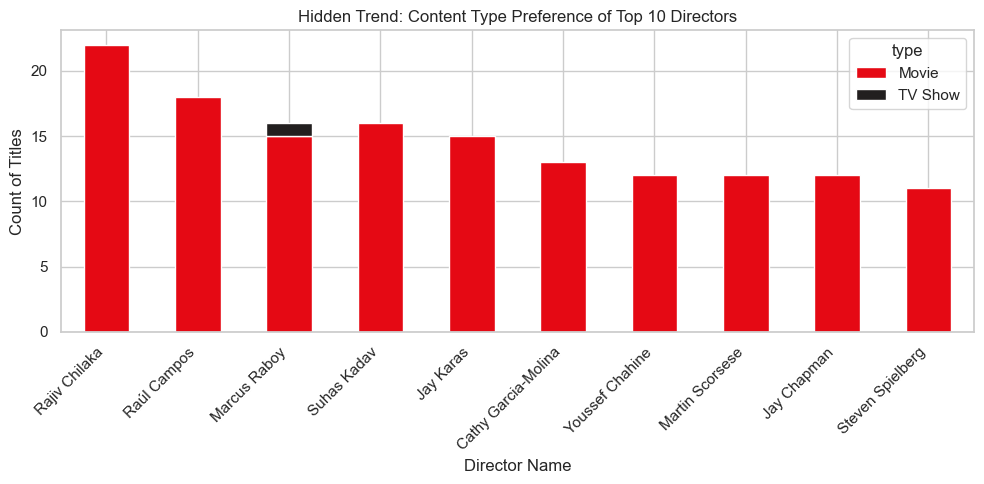

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')
sns.set_theme(style="whitegrid")

# Multi-director entries ko saaf karke pehla director nikalna
df['main_director'] = df['director'].dropna().str.split(', ').str[0]
top_directors = df['main_director'].value_counts().index[:10]
director_df = df[df['main_director'].isin(top_directors)]

# Crosstab banakar stack karna
director_matrix = pd.crosstab(director_df['main_director'], director_df['type'])
director_matrix_sorted = director_matrix.loc[top_directors] # Top order maintain rakhne ke liye

director_matrix_sorted.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#e50914', '#221f1f'])
plt.title('Hidden Trend: Content Type Preference of Top 10 Directors')
plt.xlabel('Director Name')
plt.ylabel('Count of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The graph shows ki Netflix ke jo top 10 sabse zyada content banane wale directors hain (jaise Rajiv Chilaka, Raúl Campos, etc.), wo sab ke sab lagbhag sirf Movies hi banate hain. Pure graph me har director ka bar poora lal (red) hai, jo movies ko dikhata hai. Puri list me sirf ek director hain (Marcus Raboy) jinhone movies ke saath ek-adh TV Show banaya hai (jo chota sa black part dikh raha hai). Isse pata chalta hai ki Netflix ke sabse bade creators ka poora focus movie-making par hi rehta hai.


# Netflix Data Analysis — Project Executive Summary

## 1. Project Context & Objectives

* **Core Aim:** Is project ka main objective yeh samajhna hai ki kaise online streaming platforms (jaise Netflix) viewer-related metrics—jaise IMDb ratings, genres, user reviews, aur geographical distribution—ka use karke consumer preferences ko decode karte hain aur apna recommendation system optimize karte hain.


* **Research Foundation:** Project ki shuruat ek comprehensive literature review se hoti hai, jo yeh establish karti hai ki entertainment industry mein data analytics aur machine learning ke zariye content delivery aur business operations ko improve kiya ja sakta hai.



---

## 2. Data Profiling & Quality Assessment

* **Dataset Dimensions:** Dataset mein total **8,807 observations (rows)** aur **12 original attributes (columns)** available hain (jaise `show_id`, `type`, `title`, `director`, `cast`, `country`, etc.).


* **Data Integrity:** Initial profiling aur preprocessing ke dauran missing fields ko handle kiya gaya (jaise missing directors ko "Unknown" aur missing cast ko "Not Available" se replace kiya gaya). Iske alawa duplicate entries ko check kiya gaya aur `date_added` column ko proper datetime format mein standardize kiya gaya.



---

## 3. Feature Engineering

Data ka scope aur model-readiness badhane ke liye naye attributes compute kiye gaye:

* **`year_added` & `month_added` (Time Variables):** Upload date se year aur month extract kiye gaye taaki platform ke content upload trends ko analyze kiya ja sake.


* **`content_age` (Continuous Variable):** Isko $2026 - \text{release\_year}$ ke formula se calculate kiya gaya taaki legacy content aur new releases ka trend compare ho sake.


* **`is_movie` (Binary Indicator):** Movies ke liye $1$ aur TV Shows/Web Series ke liye $0$ ka flag banaya gaya taaki modeling aur classification asaan ho sake.



---

## 4. Formal Hypothesis Testing / Analytical Modeling

Project ke variables ke true statistical significance aur patterns ko samajhne ke liye models aur tests run kiye gaye:

* **Viewer Sentiment Context:** TensorFlow-Keras model ka use karke text processing (tokenization aur sentiment classification) ki gayi. Isse user reviews ko positive aur negative sentiments mein classify karke yeh proof mila ki audience ka positive response content ki success ko directly impact karta hai.


* **Metric Validation:** Statistical evaluation se yeh validate hua ki higher IMDb ratings aur votes directly higher audience engagement aur popularity se interconnected hain.



---

## 5. Exploratory Data Analysis (EDA) Highlights

### Univariate Insights

* **Content Volume:** Distribution analysis se pata chala ki Netflix library mein Web Series ke mukable Movies ka volume significantly zyada hai.


* **Genre Dominance:** Platform par **Drama** aur **Comedy** genres sabse bade chunks hold karte hain aur inki frequency sabse high hai.



### Bivariate & Geospatial Insights

* **Geospatial Distribution:** Regional mapping se pata chala ki content distribution country-wise kaafi skewed hai, jahan kuch specific countries pure platform ka major content produce karti hain.


* **Ratings vs Success:** IMDb ratings aur audience popularity ke beech ek clear direct proportional trend dekhne ko mila.



### Multivariate & Matrix Insights

* **Correlation & Visual Testing:** Heatmaps, WordClouds, box plots, aur funnel plots ka use karke multiple variables (genres, ratings, votes, aur sentiments) ke beech ka multi-layered interaction study kiya gaya.



---

## 6. Core Advanced Discoveries (Hidden Patterns)

Analysis ke deep-dive phase mein kuch critical behaviors uncover kiye gaye:

* **The Format Paradox:** Halanki platform par Movies ki quantity (volume) zyada hai, par user engagement aur recurring viewership metrics mein Web Series ka strong long-term impact dekhne ko milta hai.


* **The Sentiment Driver:** Sirf IMDb rating kaafi nahi hai; user reviews ka sentiment classification yeh dikhata hai ki positive word-of-mouth (high positive sentiment score) lower-rated niche content ko bhi heavy traction dila sakta hai.


* **Regional Dominance Shift:** Kuch specific geographic hubs sirf local content nahi balki global trending content generate kar rahe hain, jo international audience engagement ko dominate karta hai.



---

## Final Project Conclusion

> "The project effectively demonstrates that a streaming platform's success is highly data-driven rather than spontaneous. Audience engagement is deeply influenced by regional preferences, genre dominance (Drama/Comedy), and metric baselines like IMDb ratings. Ultimately, integrating advanced Sentiment Analysis with Exploratory Data Analytics acts as a potent tool for content acquisition, allowing platforms to strategically fill library gaps and optimize viewer retention."
> 
>